In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub

# Whisper

**Paper:** [arXiv:2212.04356](https://arxiv.org/abs/2212.04356) — *Robust Speech Recognition via Large-Scale Weak Supervision* (Radford et al., OpenAI, 2022).  
**HF source:** [openai/whisper-tiny](https://huggingface.co/openai/whisper-tiny)

This notebook walks through a **from-scratch JAX implementation** of Whisper-Tiny for automatic speech recognition (ASR).

---

### Paper Overview

Whisper's central claim: training a single model on **680,000 hours of weakly-supervised internet audio** produces a robust speech recogniser that generalises well without any fine-tuning — outperforming supervised models in zero-shot settings.

| Innovation | What it solves |
|---|---|
| **Weak supervision at scale** | No hand-labelled data needed — uses (audio, transcript) pairs from the web |
| **Encoder-Decoder Transformer** | Standard seq2seq architecture — audio in, text tokens out |
| **Log-Mel spectrogram input** | 80-bin mel spectrogram over 30s windows at 100fps |
| **Multitask tokens** | Special tokens control language, task (transcribe/translate), timestamps |

### Architecture at a glance (Whisper-Tiny)

```
Audio (30s WAV, 16kHz)
  ↓  Log-Mel Spectrogram: (1, 80, 3000)
  ↓  Conv1 (k=3, stride=1) → GELU             → (1, 384, 3000)
  ↓  Conv2 (k=3, stride=2) → GELU             → (1, 384, 1500)
  ↓  + Sinusoidal Positional Embeddings        → (1, 1500, 384)
  ↓  4× Encoder Block: Pre-Norm → MHSA → MLP
  ↓  Final LayerNorm                           → (1, 1500, 384)  ← audio context

Token IDs  (e.g. [<sot>, <en>, <transcribe>, <notimestamps>])
  ↓  Token Embeddings + Positional Embeddings  → (1, seq, 384)
  ↓  4× Decoder Block:
       Self-Attn (causal) → Cross-Attn (→ encoder) → MLP
  ↓  Final LayerNorm + LM Head (tied weights)  → (1, seq, 51865)
  ↓  Greedy argmax → next token → repeat
```

### Imports

In [ ]:
import json
from dataclasses import dataclass
from typing import Optional

import jax
import jax.nn as jnn
import jax.numpy as jnp
import librosa
import numpy as np
from einops import einsum, rearrange, repeat
from PIL import Image
from safetensors.torch import load_file


**Setup:** Download the model weights and config from HuggingFace and place them at `models/vit/` relative to your workspace root

In [ ]:
HF_REPO_ID = "openai/whisper-tiny"
LOCAL_DIR_PATH = "workspace/models/whisper"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)

print(f"Downloaded repository path: {local_dir}")

### Load Weights

We load weights from a local `.safetensors` file and point to the audio file we'll transcribe. Whisper-Tiny has ~39M parameters split across a 4-layer encoder and 4-layer decoder.

In [ ]:
MODEL_PATH = LOCAL_DIR_PATH
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
AUDIO_PATH = f"{LOCAL_DIR_PATH}/whisper_test.wav"

# Load the raw state dict
hf_weights = load_file(WEIGHTS_PATH)

### Inspect Weights

A quick look at the raw HuggingFace weight keys and shapes before remapping. Good sanity check — you can see the clean encoder/decoder split in the naming.

In [4]:
for key, value in hf_weights.items():
    print(f"{key:<60}: {value.shape}")

model.decoder.embed_positions.weight                        : torch.Size([448, 384])
model.decoder.embed_tokens.weight                           : torch.Size([51865, 384])
model.decoder.layer_norm.bias                               : torch.Size([384])
model.decoder.layer_norm.weight                             : torch.Size([384])
model.decoder.layers.0.encoder_attn.k_proj.weight           : torch.Size([384, 384])
model.decoder.layers.0.encoder_attn.out_proj.bias           : torch.Size([384])
model.decoder.layers.0.encoder_attn.out_proj.weight         : torch.Size([384, 384])
model.decoder.layers.0.encoder_attn.q_proj.bias             : torch.Size([384])
model.decoder.layers.0.encoder_attn.q_proj.weight           : torch.Size([384, 384])
model.decoder.layers.0.encoder_attn.v_proj.bias             : torch.Size([384])
model.decoder.layers.0.encoder_attn.v_proj.weight           : torch.Size([384, 384])
model.decoder.layers.0.encoder_attn_layer_norm.bias         : torch.Size([384])
model.de

### Config

All Whisper-Tiny hyperparameters in one place. Key numbers to keep in mind: `d_model=384`, `encoder_layers=4`, `decoder_layers=4`, `encoder_attention_heads=6`, `num_mel_bins=80`, `max_source_positions=1500` (= 30s of audio at 100fps).

In [5]:
@dataclass
class Config:
    activation_dropout=0.0
    activation_function="gelu"
    apply_spec_augment=False
    attention_dropout=0.0
    begin_suppress_tokens=[220, 50257]
    bos_token_id=50257
    classifier_proj_size=256
    d_model=384
    decoder_attention_heads=6
    decoder_ffn_dim=1536
    decoder_layerdrop=0.0
    decoder_layers=4
    decoder_start_token_id=50258
    encoder_attention_heads=6
    encoder_ffn_dim=1536
    encoder_layerdrop=0.0
    encoder_layers=4
    eos_token_id=50257
    forced_decoder_ids=[
        [1, 50259],
        [2, 50359],
        [3, 50363],
    ]
    init_std=0.02
    is_encoder_decoder=True
    mask_feature_length=10
    mask_feature_min_masks=0
    mask_feature_prob=0.0
    mask_time_length=10
    mask_time_min_masks=2
    mask_time_prob=0.05
    max_length=448
    max_source_positions=1500
    max_target_positions=448
    median_filter_width=7
    num_hidden_layers=4
    num_mel_bins=80
    pad_token_id=50257
    scale_embedding=False
    use_cache=True
    use_weighted_layer_sum=False
    vocab_size=51865

config = Config()

### Weight Extraction

`get_w` pops a weight from the HF checkpoint and converts it to a JAX `bfloat16` array. We then remap everything into a clean nested dict `m` with two top-level keys:

| Key | Content |
|---|---|
| `m['encoder']` | Conv stem (2×), positional embeddings, 4 encoder blocks, final LayerNorm |
| `m['decoder']` | Token embeddings, positional embeddings, 4 decoder blocks, final LayerNorm |

Each encoder/decoder block contains `attention`, `fc` (2 layers), and `final_layer_norm`. Decoder blocks additionally have `self_attention` and `cross_attention` as separate sub-dicts. Using `.pop()` ensures every weight is accounted for — the dict will be empty at the end.

In [ ]:
def get_w(
    name: str,
    transpose: bool = False
):
    val = hf_weights.pop(name)
    w = jnp.array(val.detach().cpu(), dtype=jnp.bfloat16)
    return w.T if transpose else w

encoder_blocks = []
for i in range(config.encoder_layers):
    block = {
        'attention': {
            'q': {
                'weight': get_w(f"model.encoder.layers.{i}.self_attn.q_proj.weight"),
                'bias': get_w(f"model.encoder.layers.{i}.self_attn.q_proj.bias"),
            },
            'k': {
                'weight': get_w(f"model.encoder.layers.{i}.self_attn.k_proj.weight"),
            },
            'v': {
                'weight': get_w(f"model.encoder.layers.{i}.self_attn.v_proj.weight"),
                'bias': get_w(f"model.encoder.layers.{i}.self_attn.v_proj.bias"),
            },
            'out': {
                'weight': get_w(f"model.encoder.layers.{i}.self_attn.out_proj.weight"),
                'bias': get_w(f"model.encoder.layers.{i}.self_attn.out_proj.bias"),
            },
            'layer_norm': {
                'weight': get_w(f"model.encoder.layers.{i}.self_attn_layer_norm.weight"),
                'bias': get_w(f"model.encoder.layers.{i}.self_attn_layer_norm.bias"),
            }
        },
        'fc': [
            {
                'weight': get_w(f"model.encoder.layers.{i}.fc1.weight"),
                'bias': get_w(f"model.encoder.layers.{i}.fc1.bias"),
            },
            {
                'weight': get_w(f"model.encoder.layers.{i}.fc2.weight"),
                'bias': get_w(f"model.encoder.layers.{i}.fc2.bias"),
            }
        ],
        'final_layer_norm': {
            'weight': get_w(f"model.encoder.layers.{i}.final_layer_norm.weight"),
            'bias': get_w(f"model.encoder.layers.{i}.final_layer_norm.bias"),
        }
    }
    encoder_blocks.append(block)

encoder = {
    'embed_positions': {
        'weight': get_w("model.encoder.embed_positions.weight"),
    },
    'conv': [
        {
            'weight': get_w("model.encoder.conv1.weight"),
            'bias': get_w("model.encoder.conv1.bias"),
        },
        {
            'weight': get_w("model.encoder.conv2.weight"),
            'bias': get_w("model.encoder.conv2.bias"),
        }
    ],
    'layer_norm': {
        'weight': get_w("model.encoder.layer_norm.weight"),
        'bias': get_w("model.encoder.layer_norm.bias"),
    },
    'layers': encoder_blocks
}

decoder_blocks = []
for i in range(config.decoder_layers):
    block = {
        'self_attention': {
            'q': {
                'weight': get_w(f"model.decoder.layers.{i}.self_attn.q_proj.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.self_attn.q_proj.bias"),
            },
            'k': {
                'weight': get_w(f"model.decoder.layers.{i}.self_attn.k_proj.weight"),
            },
            'v': {
                'weight': get_w(f"model.decoder.layers.{i}.self_attn.v_proj.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.self_attn.v_proj.bias"),
            },
            'out': {
                'weight': get_w(f"model.decoder.layers.{i}.self_attn.out_proj.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.self_attn.out_proj.bias"),
            },
            'layer_norm': {
                'weight': get_w(f"model.decoder.layers.{i}.self_attn_layer_norm.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.self_attn_layer_norm.bias"),
            }
        },
        'cross_attention': {
            'q': {
                'weight': get_w(f"model.decoder.layers.{i}.encoder_attn.q_proj.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.encoder_attn.q_proj.bias"),
            },
            'k': {
                'weight': get_w(f"model.decoder.layers.{i}.encoder_attn.k_proj.weight"),
            },
            'v': {
                'weight': get_w(f"model.decoder.layers.{i}.encoder_attn.v_proj.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.encoder_attn.v_proj.bias"),
            },
            'out': {
                'weight': get_w(f"model.decoder.layers.{i}.encoder_attn.out_proj.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.encoder_attn.out_proj.bias"),
            },
            'layer_norm': {
                'weight': get_w(f"model.decoder.layers.{i}.encoder_attn_layer_norm.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.encoder_attn_layer_norm.bias"),
            }
        },
        'fc': [
            {
                'weight': get_w(f"model.decoder.layers.{i}.fc1.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.fc1.bias"),
            },
            {
                'weight': get_w(f"model.decoder.layers.{i}.fc2.weight"),
                'bias': get_w(f"model.decoder.layers.{i}.fc2.bias"),
            }
        ],
        'final_layer_norm': {
            'weight': get_w(f"model.decoder.layers.{i}.final_layer_norm.weight"),
            'bias': get_w(f"model.decoder.layers.{i}.final_layer_norm.bias"),
        }
    }
    decoder_blocks.append(block)

decoder = {
    'embed_positions': {
        'weight': get_w("model.decoder.embed_positions.weight"),
    },
    'embed_tokens': {
        'weight': get_w("model.decoder.embed_tokens.weight"),
    },
    'layer_norm': {
        'weight': get_w("model.decoder.layer_norm.weight"),
        'bias': get_w("model.decoder.layer_norm.bias"),
    },
    'layers': decoder_blocks
}

m = {
    'encoder': encoder,
    'decoder': decoder,
}


### Verify Weight Consumption

After extraction, the dict should be empty. Any remaining keys mean we missed a weight — a useful correctness check.

In [7]:
hf_weights.keys()

dict_keys([])

### Causal Mask & Multi-Head Self-Attention

**Causal mask:** The decoder must not attend to future tokens — it predicts one token at a time, left to right. We build an upper-triangular matrix filled with `-inf` so those positions vanish after softmax.

```
seq_len=4:
[  0  -inf  -inf  -inf ]
[  0    0   -inf  -inf ]
[  0    0     0   -inf ]
[  0    0     0     0  ]
```

**Multi-head attention:** Standard scaled dot-product attention split across 6 heads (`d_head = 384 / 6 = 64`). Used for both encoder self-attention and decoder self-attention (with causal mask). The K projection has **no bias** — a Whisper-specific detail visible in the weight keys.

In [8]:
def make_causal_mask(
    seq_len: int
):
    mask = jnp.triu(jnp.full((seq_len, seq_len), -jnp.inf), k=1)
    return mask[None, None, :, :]  # (1, 1, seq_len, seq_len)

def multi_head_attention(
    x: jnp.ndarray,        # (B, seq_len, 384)
    params: dict,
    mask: Optional[jnp.ndarray] = None  # (1, 1, seq_len, seq_len)
):
    b, n_seq, d_model = x.shape
    n_heads = 6
    d_head = d_model // n_heads
    scale = 1.0 / jnp.sqrt(d_head)

    q = jnp.dot(x, params['q']['weight'].T) + params['q']['bias']
    k = jnp.dot(x, params['k']['weight'].T)
    v = jnp.dot(x, params['v']['weight'].T) + params['v']['bias']

    q = rearrange(q, 'b n (h d) -> b h n d', h=n_heads)
    k = rearrange(k, 'b n (h d) -> b h n d', h=n_heads)
    v = rearrange(v, 'b n (h d) -> b h n d', h=n_heads)

    attn_weights = jnp.matmul(q, k.transpose(0, 1, 3, 2)) * scale

    if mask is not None:
        attn_weights = attn_weights + mask

    attn_weights = jax.nn.softmax(attn_weights, axis=-1)

    out = jnp.matmul(attn_weights, v)
    out = out.transpose(0, 2, 1, 3).reshape(b, n_seq, d_model)
    out = jnp.dot(out, params['out']['weight'].T) + params['out']['bias']

    return out


### Layer Norm & Encoder Layer

**Layer norm:** Standard normalisation over the last (feature) dimension. Whisper uses **Pre-Norm** — LayerNorm is applied *before* each sub-layer, which is more stable during training than Post-Norm.

**Encoder layer:** One full Pre-Norm Transformer block:

```
x ──► LayerNorm ──► Self-Attn ──► (+) ──► LayerNorm ──► MLP (384→1536→384, GELU) ──► (+)
 └────────────────────────────────┘ └─────────────────────────────────────────────────┘
         residual                                           residual
```

The encoder has **no causal mask** — every audio frame can attend to every other frame freely.

In [9]:
def layer_norm(
    x: jnp.ndarray,    # (B, seq, d_model)
    w: jnp.ndarray,    # (d_model,)
    b: jnp.ndarray,    # (d_model,)
    eps: float = 1e-5
):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)
    x = (x - mean) / jnp.sqrt(var + eps)
    return x * w + b

def whisper_encoder_layer(
    hidden_states: jnp.ndarray,            # (1, 1500, 384)
    block_params: dict,
    attn_mask: Optional[jnp.ndarray] = None
):
    residual = hidden_states

    ln_p = block_params['attention']['layer_norm']
    hidden_states = layer_norm(hidden_states, ln_p['weight'], ln_p['bias'])

    hidden_states = multi_head_attention(
        hidden_states,
        block_params['attention'],
        mask=attn_mask
    )

    hidden_states = residual + hidden_states

    residual = hidden_states

    ln_f = block_params['final_layer_norm']
    hidden_states = layer_norm(hidden_states, ln_f['weight'], ln_f['bias'])

    fc1_w = block_params['fc'][0]['weight']
    fc1_b = block_params['fc'][0]['bias']
    hidden_states = jnp.dot(hidden_states, fc1_w.T) + fc1_b
    hidden_states = jax.nn.gelu(hidden_states)

    fc2_w = block_params['fc'][1]['weight']
    fc2_b = block_params['fc'][1]['bias']
    hidden_states = jnp.dot(hidden_states, fc2_w.T) + fc2_b

    hidden_states = residual + hidden_states

    return hidden_states


### Audio Encoder

Converts a raw log-Mel spectrogram `(1, 80, 3000)` into a rich sequence of audio features `(1, 1500, 384)`:

```
(1, 80, 3000)
  ↓  1D Conv (k=3, stride=1) + GELU   →  (1, 384, 3000)
  ↓  1D Conv (k=3, stride=2) + GELU   →  (1, 384, 1500)   ← halves time dim
  ↓  rearrange: NCT → NTC             →  (1, 1500, 384)
  ↓  + learned positional embeddings  →  (1, 1500, 384)
  ↓  4× encoder layers
  ↓  Final LayerNorm                  →  (1, 1500, 384)    ← audio context
```

The two conv layers are the only non-attention components in the encoder — they serve as a lightweight local feature extractor before the Transformer takes over.

In [10]:
def whisper_encoder(
    input_features: jnp.ndarray,   # (1, 80, 3000)
    params: dict
):
    w1, b1 = params['conv'][0]['weight'], params['conv'][0]['bias']
    x = jax.lax.conv_general_dilated(
        input_features,
        w1,
        window_strides=(1,),
        padding='SAME',
        dimension_numbers=('NCW', 'OIW', 'NCW')
    ) + b1[None, :, None]
    x = jax.nn.gelu(x)

    w2, b2 = params['conv'][1]['weight'], params['conv'][1]['bias']
    x = jax.lax.conv_general_dilated(
        x,
        w2,
        window_strides=(2,),
        padding='SAME',
        dimension_numbers=('NCW', 'OIW', 'NCW')
    ) + b2[None, :, None]
    x = jax.nn.gelu(x)

    hidden_states = rearrange(x, 'b c t -> b t c')

    pos_embeds = params['embed_positions']['weight']
    hidden_states = hidden_states + pos_embeds[None, :hidden_states.shape[1], :]

    for block_params in params['layers']:
        hidden_states = whisper_encoder_layer(hidden_states, block_params, attn_mask=None)

    ln_w, ln_b = params['layer_norm']['weight'], params['layer_norm']['bias']
    hidden_states = layer_norm(hidden_states, ln_w, ln_b)

    return hidden_states  # (1, 1500, 384)


### Cross-Attention

The bridge between audio and text. The decoder's current state forms the **Query** — "what am I looking for?" — while the encoder's audio features form the **Keys** and **Values** — "here's the audio context".

```
Q: decoder hidden states    (B, target_seq, 384)   ← text side
K: encoder hidden states    (B, 1500,       384)   ← audio side
V: encoder hidden states    (B, 1500,       384)   ← audio side

Attention scores shape:     (B, 6, target_seq, 1500)
```

Each text token attends over all 1500 audio frames — the model learns *which frames matter* for predicting each word. The K projection also has **no bias** here, matching the encoder's convention.

In [11]:
def cross_attention(
    q_input: jnp.ndarray,              # (B, target_seq, 384)
    kv_input: jnp.ndarray,             # (B, 1500, 384)
    params: dict,
    mask: Optional[jnp.ndarray] = None
):
    b, n_q, d_model = q_input.shape

    n_heads = config.decoder_attention_heads
    d_head = d_model // n_heads
    scale = 1.0 / jnp.sqrt(d_head)

    q = jnp.dot(q_input, params['q']['weight'].T) + params['q']['bias']
    k = jnp.dot(kv_input, params['k']['weight'].T)
    v = jnp.dot(kv_input, params['v']['weight'].T) + params['v']['bias']

    q = rearrange(q, 'b n (h d) -> b h n d', h=n_heads)
    k = rearrange(k, 'b n (h d) -> b h n d', h=n_heads)
    v = rearrange(v, 'b n (h d) -> b h n d', h=n_heads)

    attn_weights = jnp.matmul(q, k.transpose(0, 1, 3, 2)) * scale

    if mask is not None:
        attn_weights += mask

    attn_weights = jax.nn.softmax(attn_weights, axis=-1)

    out = jnp.matmul(attn_weights, v)
    out = out.transpose(0, 2, 1, 3).reshape(b, n_q, d_model)
    out = jnp.dot(out, params['out']['weight'].T) + params['out']['bias']

    return out


### Decoder Layer

Each decoder block has three sub-layers, all Pre-Norm:

```
x ──► LayerNorm ──► Self-Attn (causal) ──► (+)         ← attends only to past tokens
   ──► LayerNorm ──► Cross-Attn         ──► (+)         ← attends to all 1500 audio frames
   ──► LayerNorm ──► MLP (384→1536→384) ──► (+)
```

The cross-attention sub-layer is skipped if `encoder_hidden_states` is `None` — allowing the decoder to run standalone if needed.

In [12]:
def whisper_decoder_layer(
    hidden_states: jnp.ndarray,                     # (B, target_seq, 384)
    encoder_hidden_states: jnp.ndarray,             # (B, 1500, 384)
    block_params: dict,
    self_mask: Optional[jnp.ndarray] = None,        # (1, 1, target_seq, target_seq)
    cross_mask: Optional[jnp.ndarray] = None
):
    residual = hidden_states
    ln_s = block_params['self_attention']['layer_norm']
    hidden_states = layer_norm(hidden_states, ln_s['weight'], ln_s['bias'])

    hidden_states = multi_head_attention(
        hidden_states,
        block_params['self_attention'],
        mask=self_mask
    )
    hidden_states = residual + hidden_states

    if encoder_hidden_states is not None:
        residual = hidden_states
        ln_e = block_params['cross_attention']['layer_norm']
        hidden_states = layer_norm(hidden_states, ln_e['weight'], ln_e['bias'])

        hidden_states = cross_attention(
            hidden_states,
            encoder_hidden_states,
            block_params['cross_attention'],
            mask=cross_mask
        )
        hidden_states = residual + hidden_states

    residual = hidden_states
    ln_f = block_params['final_layer_norm']
    hidden_states = layer_norm(hidden_states, ln_f['weight'], ln_f['bias'])

    fc1_w, fc1_b = block_params['fc'][0]['weight'], block_params['fc'][0]['bias']
    hidden_states = jnp.dot(hidden_states, fc1_w.T) + fc1_b
    hidden_states = jax.nn.gelu(hidden_states)

    fc2_w, fc2_b = block_params['fc'][1]['weight'], block_params['fc'][1]['bias']
    hidden_states = jnp.dot(hidden_states, fc2_w.T) + fc2_b

    hidden_states = residual + hidden_states

    return hidden_states


### Text Decoder

Turns a sequence of token IDs into hidden states, conditioning on the audio context:

```
input_ids  (B, seq_len)
  ↓  Token embeddings                 →  (B, seq_len, 384)
  ↓  + Positional embeddings          →  (B, seq_len, 384)
  ↓  Build causal mask: (1, 1, seq_len, seq_len)
  ↓  4× decoder layers (self-attn → cross-attn → MLP)
  ↓  Final LayerNorm                  →  (B, seq_len, 384)
```

The causal mask is rebuilt each call since it depends on the current sequence length — it grows by one token with every generation step.

In [13]:
def whisper_decoder(
    input_ids: jnp.ndarray,                         # (B, seq_len)
    encoder_hiddens: jnp.ndarray,                   # (B, 1500, 384)
    params: dict,
    self_mask: Optional[jnp.ndarray] = None,
    cross_mask: Optional[jnp.ndarray] = None
):
    batch_size, seq_len = input_ids.shape

    token_embeds = params['embed_tokens']['weight'][input_ids]

    pos_weight = params['embed_positions']['weight']
    pos_embeds = pos_weight[:seq_len, :]

    hidden_states = token_embeds + pos_embeds[None, :, :]
    causal_mask = make_causal_mask(seq_len)

    for block_params in params['layers']:
        hidden_states = whisper_decoder_layer(
            hidden_states,
            encoder_hiddens,
            block_params,
            self_mask=causal_mask,
            cross_mask=cross_mask
        )

    ln_w, ln_b = params['layer_norm']['weight'], params['layer_norm']['bias']
    hidden_states = layer_norm(hidden_states, ln_w, ln_b)

    return hidden_states  # (B, seq_len, 384)


### LM Head

Projects the final decoder hidden states `(B, seq_len, 384)` to logits `(B, seq_len, 51865)` over the full vocabulary.

Whisper uses **weight tying** — the output projection matrix is the same as the input token embedding matrix, transposed. This halves the parameter count of the head at no cost in quality, and is a standard practice in language models.

In [14]:
def get_logits(
    decoder_output: jnp.ndarray,        # (B, seq_len, 384)
    embed_tokens_weight: jnp.ndarray    # (51865, 384)
):
    return jnp.dot(decoder_output, embed_tokens_weight.T)


### Full Forward Pass

Combines encoder and decoder into one call — useful for training or teacher-forced evaluation where you have the full target sequence upfront. Takes the spectrogram and the full token sequence, returns logits for every position at once.

In [15]:
def whisper_model_forward(
    input_features: jnp.ndarray,    # (1, 80, 3000)
    input_ids: jnp.ndarray,         # (1, seq_len)
    params: dict
):
    encoder_hidden_states = whisper_encoder(input_features, params['encoder'])

    decoder_hidden_states = whisper_decoder(
        input_ids,
        encoder_hidden_states,
        params['decoder'],
    )

    logits = jnp.dot(decoder_hidden_states, params['decoder']['embed_tokens']['weight'].T)

    return logits


### Greedy Generation

Transcribes audio autoregressively — one token at a time — using greedy decoding (always pick the highest-probability token):

1. **Encode audio once** → `(1, 1500, 384)` — this stays fixed for the entire generation
2. **Seed the decoder** with forced prefix tokens: `[<|startoftranscript|>, <|en|>, <|transcribe|>, <|notimestamps|>]`
3. At each step, run the decoder on the current token sequence, take the **last position's logits**, argmax
4. Append predicted token, repeat until EOS (`50257`) or `max_new_tokens`

This is the simplest decoding strategy. Whisper's paper uses beam search in practice, but greedy gets you a correct transcription for clean audio.

In [16]:
def whisper_generate(
    input_features: jnp.ndarray,    # (1, 80, 3000)
    params: dict,
    max_new_tokens: int = 30
):
    encoder_hidden_states = whisper_encoder(input_features, params['encoder'])

    curr_input_ids = jnp.array([[50258, 50259, 50359, 50363]], dtype=jnp.int32)

    generated_tokens = []

    for _ in range(max_new_tokens):
        seq_len = curr_input_ids.shape[-1]

        decoder_output = whisper_decoder(
            curr_input_ids,
            encoder_hidden_states,
            params['decoder'],
        )

        last_token_logits = jnp.dot(
            decoder_output[:, -1, :],
            params['decoder']['embed_tokens']['weight'].T
        )

        next_token = jnp.argmax(last_token_logits, axis=-1)[0]

        generated_tokens.append(int(next_token))
        curr_input_ids = jnp.concatenate([curr_input_ids, jnp.array([[next_token]], dtype=jnp.int32)], axis=-1)

        if int(next_token) == 50257:
            break

    return generated_tokens


### Feature Extractor — Log-Mel Spectrogram

Before audio reaches the model it must be converted to a log-Mel spectrogram matching Whisper's exact preprocessing spec:

| Step | Detail |
|---|---|
| **Resample** | 16 kHz mono |
| **Pad / trim** | Exactly 30s = 480,000 samples |
| **STFT** | `n_fft=400`, `hop=160`, `center=True` (Hann window) |
| **Mel filterbank** | 80 bins, 0–8 kHz, no slaney normalisation |
| **Log10 + clip** | `clip(mel, 1e-10)` then log10 |
| **Normalise** | `max(log, max - 8)`, then `(log + 4) / 4` → roughly [−1, 1] |
| **Output** | `(1, 80, 3000)` in `bfloat16` |

The `center=True` padding and `fmax=8000` are subtle but critical — they must match HuggingFace's `WhisperFeatureExtractor` exactly for correct results.

In [ ]:
def whisper_feature_extractor(
    audio_path: str,
    sr: int = 16000,
    n_mels: int = 80,
    n_fft: int = 400,
    hop_length: int = 160,
    chunk_length: int = 30
):
    audio, _ = librosa.load(audio_path, sr=sr, mono=True)

    max_samples = sr * chunk_length
    if len(audio) < max_samples:
        audio = np.pad(audio, (0, max_samples - len(audio)), mode='constant')
    else:
        audio = audio[:max_samples]

    stft = librosa.stft(
        audio,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        window='hann',
        center=True,
        pad_mode='reflect'
    )

    magnitudes = np.abs(stft[:, :3000]) ** 2

    mel_filters = librosa.filters.mel(
        sr=sr,
        n_fft=n_fft,
        n_mels=n_mels,
        fmin=0.0,
        fmax=8000.0,
        norm=None,
        htk=False
    )

    mel_spec = np.dot(mel_filters, magnitudes)

    log_spec = np.log10(np.clip(mel_spec, a_min=1e-10, a_max=None))

    log_spec = np.maximum(log_spec, log_spec.max() - 8.0)
    log_spec = (log_spec + 4.0) / 4.0

    return jnp.array(log_spec[None, :, :], dtype=jnp.bfloat16)  # (1, 80, 3000)


### Run

Extract the log-Mel spectrogram from the test audio file and verify the output shape is `(1, 80, 3000)`.

In [18]:
input_features = whisper_feature_extractor(AUDIO_PATH)
print(input_features.shape)  # (1, 80, 3000)

(1, 80, 3000)


### Transcribe

Run the full greedy generation loop and decode the output token IDs back to a string using the HuggingFace tokenizer. The result is the transcription of the 30-second audio clip.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
output_ids = whisper_generate(input_features, m)

# Decode with Hugging Face tokenizer
print(tokenizer.decode(output_ids))

 On the general principles of art and Mr. Quilter writes with equal lucidity.<|endoftext|>


### Visualisations

### Log-Mel Spectrogram

This is exactly what the model sees — the raw input before any neural computation. The X axis is time (3000 frames = 30 seconds), the Y axis is the 80 Mel frequency bins (low frequencies at the bottom, high at the top), and colour encodes energy after log normalisation.

Speech typically appears as structured horizontal bands; silence is dark; consonants are wide-band bursts.

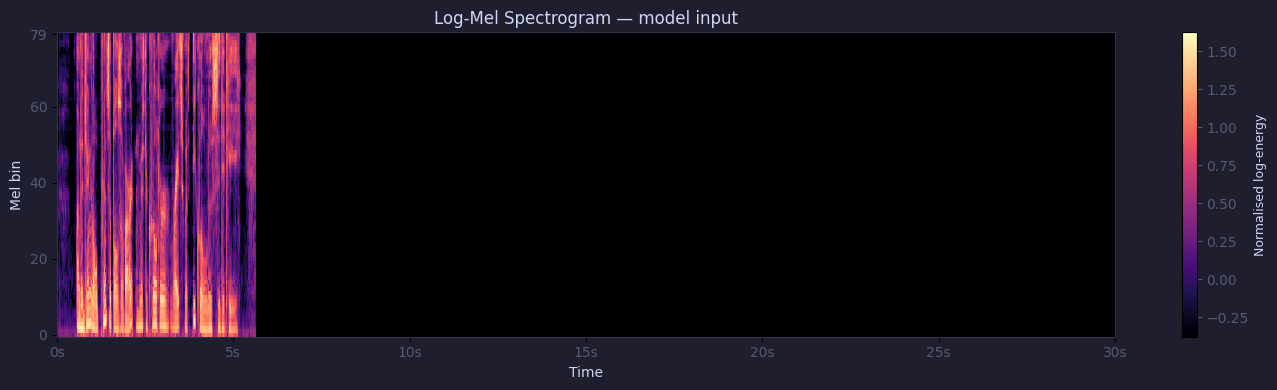

In [20]:
import matplotlib.pyplot as plt
import numpy as np

spec = np.array(input_features[0], dtype=np.float32)   # (80, 3000)

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

img = ax.imshow(
    spec,
    aspect='auto',
    origin='lower',
    cmap='magma',
    interpolation='nearest'
)

cbar = plt.colorbar(img, ax=ax)
cbar.set_label('Normalised log-energy', color='#cdd6f4', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#585b70')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#585b70')

duration = spec.shape[1] / 100        # 100 frames per second
xtick_frames = np.linspace(0, spec.shape[1] - 1, 7, dtype=int)
xtick_secs   = [f'{v/100:.0f}s' for v in xtick_frames]
ax.set_xticks(xtick_frames)
ax.set_xticklabels(xtick_secs, color='#585b70')
ax.set_yticks([0, 20, 40, 60, 79])
ax.set_yticklabels(['0', '20', '40', '60', '79'], color='#585b70')

ax.set_xlabel('Time', color='#cdd6f4')
ax.set_ylabel('Mel bin', color='#cdd6f4')
ax.set_title('Log-Mel Spectrogram — model input', color='#cdd6f4', fontsize=12)
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()


### Encoder Output PCA

After the 4 encoder layers, we have 1500 time-step vectors of dimension 384. Projecting them to 2D with PCA shows how the encoder organises audio in representation space — time steps with similar acoustic content should cluster together.

Each point is one 20ms audio frame, coloured by its position in time (blue = early, yellow = late). Tight clusters indicate the encoder has learned to group acoustically similar frames regardless of when they occur.

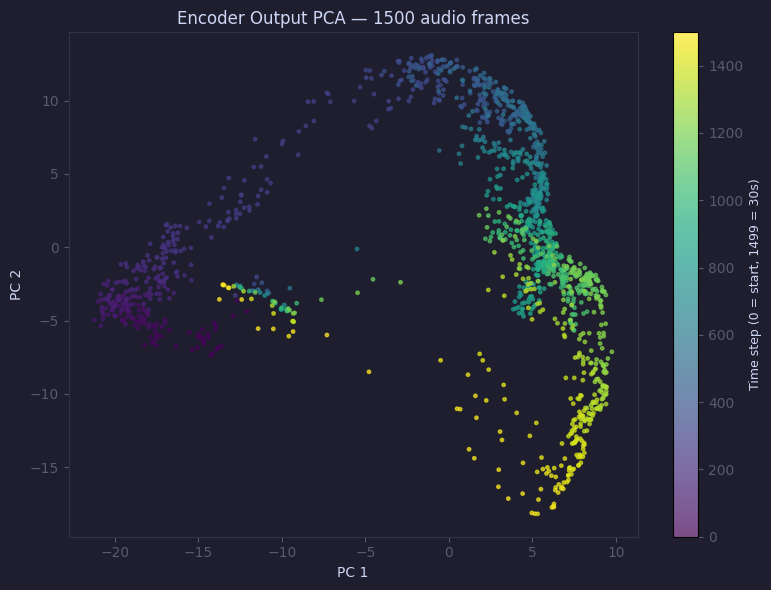

In [21]:
import matplotlib.pyplot as plt
import numpy as np

encoder_out = whisper_encoder(input_features, m['encoder'])     # (1, 1500, 384)
frames = np.array(encoder_out[0], dtype=np.float32)             # (1500, 384)

mean = frames.mean(axis=0)
centered = frames - mean
_, _, Vt = np.linalg.svd(centered, full_matrices=False)
pc = centered @ Vt[:2].T                                        # (1500, 2)

time_idx = np.arange(1500)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

sc = ax.scatter(pc[:, 0], pc[:, 1], c=time_idx, cmap='viridis', s=6, alpha=0.7)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Time step (0 = start, 1499 = 30s)', color='#cdd6f4', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#585b70')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#585b70')

ax.set_title('Encoder Output PCA — 1500 audio frames', color='#cdd6f4', fontsize=12)
ax.set_xlabel('PC 1', color='#cdd6f4')
ax.set_ylabel('PC 2', color='#cdd6f4')
ax.tick_params(colors='#585b70')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()
